#Preparation


Pada lokal buatlah virtual environemnt terlebih dahulu untuk memisahkan proyek-proyek Python sehingga tidak saling bertabrakan dengan library yang berbeda.

```
python -m venv namavirtualenviromentmu
```
Aktifkan virtual environmentmu dengan cara menuliskan pada command prompt (Windows)
`.\namavirtualenviromentmu\Scripts\activate` atau terminal (Linux) `source namavirtualenviromentmu/bin/activate
`



In [ ]:
#install tensorflow
pip install tensorflow

# atau versi GPU (jika mendukung)
pip install tensorflow-gpu

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.17.0


## Kenapa disebut Tensorflow

Tensor adalah struktur dasar dalam TensorFlow yang mewakili data dalam berbagai dimensi (scalar, vector, matrix, tensor). Tensor adalah array multidimensi.<br>
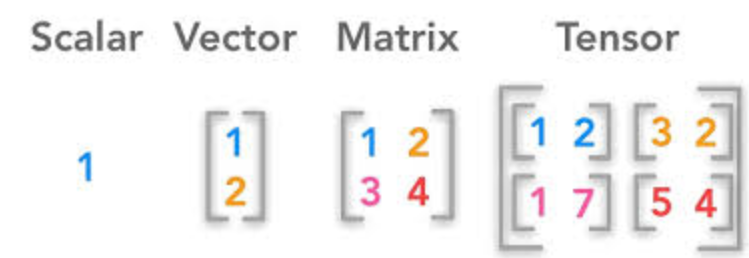

In [ ]:
#Scalar adalah Tensor dengan 0 dimensi, misalnya angka tunggal.

scalar = tf.constant(1)
print(scalar)

tf.Tensor(1, shape=(), dtype=int32)


In [ ]:
#Vector adalah Tensor dengan 1 dimensi, misalnya daftar angka.

vector = tf.constant([1, 2])
print(vector)

tf.Tensor([1 2], shape=(2,), dtype=int32)


In [ ]:
#Matrix adalah Tensor dengan 2 dimensi.

matrix = tf.constant([[1, 2], [3, 4]])
print(matrix)

tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)


#Tensorflow sederhana

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Membuat model Sequential
model = Sequential([
    Dense(128, activation='relu', input_shape=(28, 28)),
    Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Melihat ringkasan model
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 28, 128)             │           3,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 28, 10)              │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,002 (19.54 KB)

 Trainable params: 5,002 (19.54 KB)

 Non-trainable params: 0 (0.00 B)

**Perhitungan Jumlah Parameter:** <br>
Layer Pertama:<br>
Pada layer pertama (Dense(128) dengan input shape (28,)), parameter dihitung berdasarkan hubungan antara input dan output neuron:
* Jumlah Weights = Jumlah input × Jumlah neuron di output layer = 28 × 128 = 3,584.
* Jumlah Biases = Jumlah neuron di output layer = 128.
* Total Param = 3,584 (weights) + 128 (biases) = 3,712.

Layer Kedua:<br>
Pada layer kedua (Dense(10) dengan input dari 128 unit di layer pertama):

* Jumlah Weights = Jumlah input × Jumlah neuron di output layer = 128 × 10 = 1,280.
* Jumlah Biases = Jumlah neuron di output layer = 10.
* Total Param = 1,280 (weights) + 10 (biases) = 1,290.


## Istilah pada Tensorflow

* `tensorflow.keras` adalah fungsi API untuk membangun dan melatih model machine learning <br>
* `Sequential` adalah jenis model yang paling umum digunakan, di mana lapisan (layers) model ditumpuk secara berurutan. <br>
* `Dense` adalah layer dasar dalam neural network di mana setiap neuron terhubung secara penuh (fully connected) ke neuron di lapisan berikutnya. Layer ini digunakan untuk model feedforward.


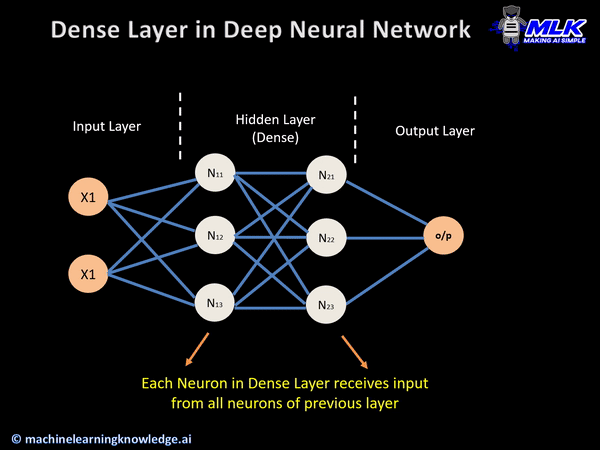

### Membuat Model

`Dense(128, activation='relu', input_shape=(28, 28))`: <br>

* `Dense(128)`: Layer pertama adalah fully connected layer (dense layer) dengan 128 neuron. Artinya, setiap neuron dalam lapisan ini terhubung ke semua neuron di lapisan sebelumnya.
* `activation='relu'`: Menggunakan fungsi aktivasi ReLU (Rectified Linear Unit), yang merupakan fungsi aktivasi yang sangat populer di jaringan saraf tiruan. Fungsi ReLU akan mengubah input negatif menjadi nol dan input positif dibiarkan tetap.
* `input_shape=(28, 28)`: Menunjukkan ukuran input yang diterima oleh model. Dalam hal ini, input adalah gambar dengan ukuran 28x28 piksel (biasanya untuk dataset gambar seperti MNIST). Dimensi input (28, 28) ini diteruskan hanya pada layer pertama. <br>

`Dense(10, activation='softmax'):` <br>
* `Dense(10)`: Layer kedua adalah output layer dengan 10 neuron. Biasanya, angka ini sesuai dengan jumlah kelas yang akan diprediksi. Dalam contoh ini, model digunakan untuk klasifikasi 10 kelas (misalnya untuk dataset MNIST, yang memiliki 10 digit angka 0-9).
* `activation='softmax'`: Fungsi aktivasi softmax digunakan di output layer untuk klasifikasi multi-kelas. Softmax mengubah output menjadi probabilitas, di mana setiap kelas akan diberikan nilai probabilitas yang jumlahnya selalu 1.





### Compile Model

`model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])`

* `optimizer='adam'`: Optimizer yang digunakan adalah Adam (Adaptive Moment Estimation), yang merupakan salah satu optimizer yang paling populer dan efisien untuk banyak jenis model machine learning.
* `loss='sparse_categorical_crossentropy'`: Fungsi loss ini digunakan untuk klasifikasi multi-kelas, khususnya ketika target adalah label integer. Ini adalah fungsi loss yang umum untuk masalah klasifikasi multi-kelas.
* `metrics=['accuracy']`: Metrik evaluasi yang digunakan adalah accuracy (akurasi), yang menghitung persentase prediksi yang benar terhadap seluruh data uji.

# Regresi Linear with Tensorflow

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('/content/sample_data/california_housing_train.csv')
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


In [ ]:
X = data.iloc[:, :-1]  # Semua kolom kecuali kolom terakhir
y = data.iloc[:, -1]   # Kolom terakhir sebagai target

In [ ]:
# Membagi dataset menjadi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Modifikasi model dengan hidden layers, dropout, dan learning rate yang lebih rendah
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=[X_train.shape[1]]),
    tf.keras.layers.Dropout(0.3),  # Menambahkan dropout untuk regularisasi
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1)
])
# Compile dengan optimizer Adam dan learning rate lebih rendah
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Berhenti setelah 10 epoch tanpa perbaikan
    restore_best_weights=True  # Kembali ke weights terbaik
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=500,
    validation_split=0.2,
    callbacks=[early_stopping]  # Menambahkan early stopping ke dalam training
)

Epoch 1/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 43378143232.0000 - val_loss: 25438339072.0000
Epoch 2/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 26811774976.0000 - val_loss: 22683891712.0000
Epoch 3/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 22624194560.0000 - val_loss: 17619927040.0000
Epoch 4/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 18003220480.0000 - val_loss: 12487527424.0000
Epoch 5/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12757176320.0000 - val_loss: 11180555264.0000
Epoch 6/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12061486080.0000 - val_loss: 10876317696.0000
Epoch 7/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 11948996608.0000 - val_loss: 10782338048.0000
Epoch 8/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 11978658816.0000 - val_loss: 10527918080.0000
Epoch 9/500
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11588132864.0000 - val_loss: 10395555840.0000
Epoch 10/500
340/340 ━━━━━━━━━━━━━━━━

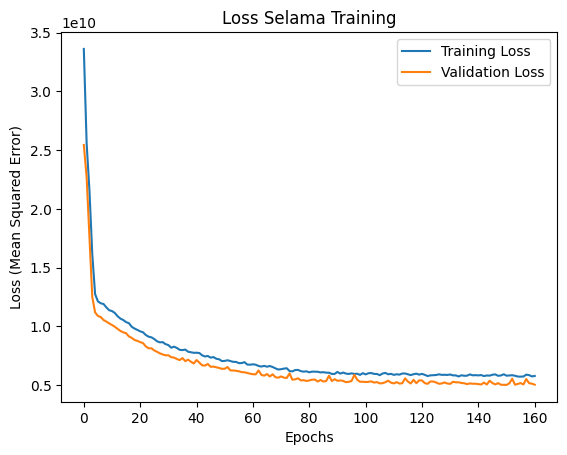

In [ ]:
# Visualisasi loss selama training
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Selama Training')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.show()

In [ ]:
# Evaluasi model pada data testing
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss (Mean Squared Error): {test_loss}")

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4927219200.0000
Test Loss (Mean Squared Error): 4671572480.0


107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


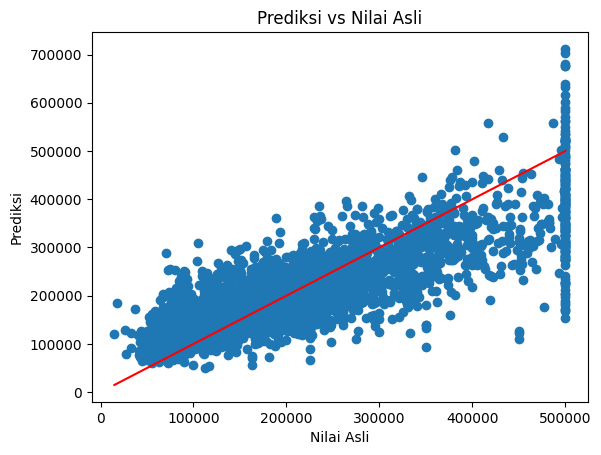

In [ ]:
# Membuat prediksi pada data testing
y_pred = model.predict(X_test)

# Plot prediksi vs nilai asli
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Garis referensi
plt.title('Prediksi vs Nilai Asli')
plt.xlabel('Nilai Asli')
plt.ylabel('Prediksi')
plt.show()

In [ ]:
from sklearn.metrics import r2_score

# Hitung R2 Score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2}")

R² Score: 0.6609605413479254


In [ ]:
# Mendapatkan bobot dan bias dari model
weights = model.layers[0].get_weights()[0]
bias = model.layers[0].get_weights()[1]

print("Persamaan Model:")
print("y = ", end="")
for i in range(X_train.shape[1]):
  print(f"{weights[i][0]:.4f} * x{i+1} + ", end="")

print(f"{bias[0]:.4f}")

Persamaan Model:
y = -0.3105 * x1 + -1.2049 * x2 + 0.8418 * x3 + 0.1037 * x4 + -0.1616 * x5 + -0.3251 * x6 + 0.4848 * x7 + 11.2584 * x8 + 0.3574


In [ ]:
.pkl
.h5
.sav
.ggu
.onnx
.tflite

# Computer Vision with Tensorflow

In [9]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [10]:
# Memuat dataset CIFAR-10 dari tensorflow_datasets
dataset, info = tfds.load('cifar10', as_supervised=True, with_info=True)

# Membagi dataset menjadi data training dan data testing
train_data, test_data = dataset['train'], dataset['test']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.9S94MJ_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.9S94MJ_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


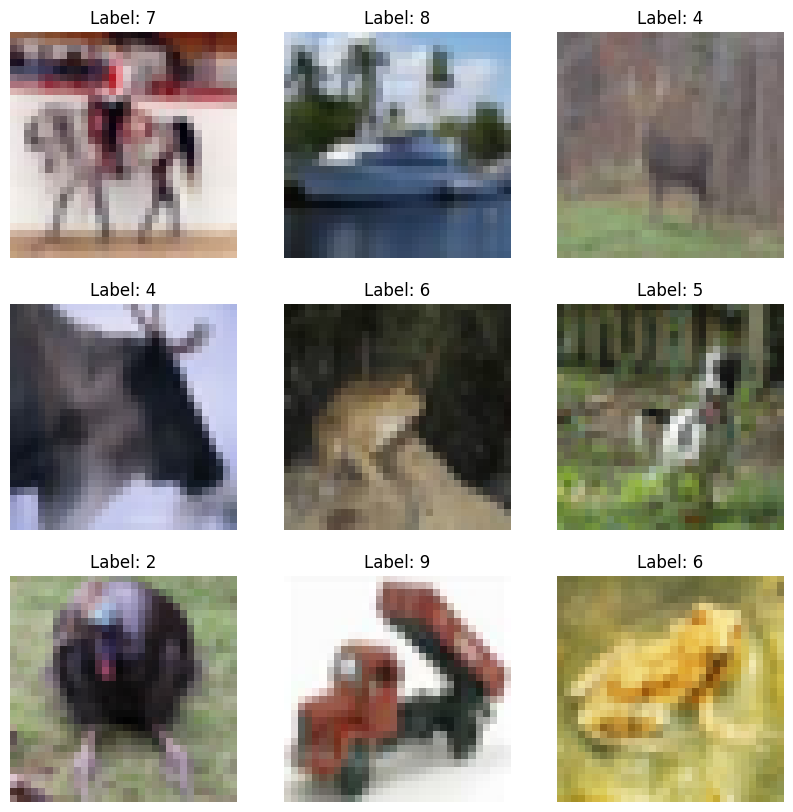

In [13]:
# Menampilkan beberapa contoh gambar dari dataset CIFAR-10
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_data.take(9)):
    plt.subplot(3, 3, i+1)
    plt.imshow(image)
    plt.title(f"Label: {label.numpy()}")
    plt.axis('off')
plt.show()

In [14]:
# Normalisasi nilai piksel gambar ke rentang [0, 1]
def normalize_img(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # Normalisasi
    return image, label

# Menerapkan preprocessing ke data training dan testing
train_data = train_data.map(normalize_img).shuffle(10000).batch(64).prefetch(tf.data.AUTOTUNE)
test_data = test_data.map(normalize_img).batch(64).prefetch(tf.data.AUTOTUNE)

In [15]:
# Membangun model CNN
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),  # Layer Convolutional 1
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),  # MaxPooling untuk mengurangi dimensi

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),  # Layer Convolutional 2
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),  # Layer Convolutional 3
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Flatten(),  # Flattening layer untuk meratakan data
    tf.keras.layers.Dense(128, activation='relu'),  # Fully connected layer
    tf.keras.layers.Dense(10, activation='softmax')  # Output layer dengan softmax untuk klasifikasi 10 kelas
])

# Compile model dengan optimizer Adam dan fungsi loss categorical crossentropy
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# Melatih model dengan data training dan validasi pada data testing
history = model.fit(train_data, epochs=10, validation_data=test_data)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 87s 107ms/step - accuracy: 0.3313 - loss: 1.8204 - val_accuracy: 0.5360 - val_loss: 1.3013
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 130s 93ms/step - accuracy: 0.5619 - loss: 1.2465 - val_accuracy: 0.5789 - val_loss: 1.1946
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 75s 95ms/step - accuracy: 0.6259 - loss: 1.0650 - val_accuracy: 0.6210 - val_loss: 1.0773
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 96ms/step - accuracy: 0.6663 - loss: 0.9535 - val_accuracy: 0.6655 - val_loss: 0.9720
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 92ms/step - accuracy: 0.6984 - loss: 0.8592 - val_accuracy: 0.6817 - val_loss: 0.9253
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.7240 - loss: 0.7938 - val_accuracy: 0.6876 - val_loss: 0.9108
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 94ms/step - accuracy: 0.7436 - loss: 0.7368 - val_accuracy: 0.6934 - val_loss: 0.9099
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 93ms/step - accuracy: 0.7647 - loss: 0.6758 

157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.7185 - loss: 0.8523
Test Accuracy: 0.7127


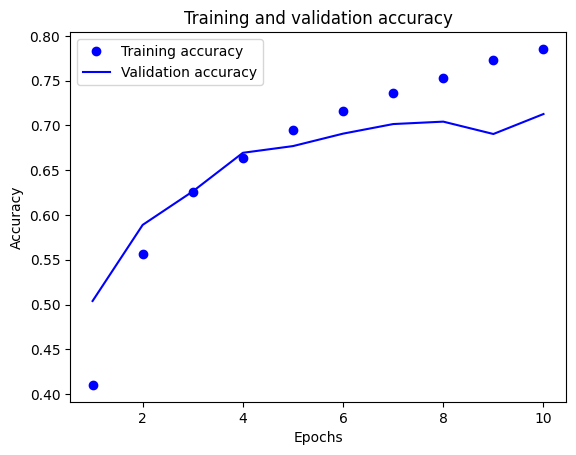

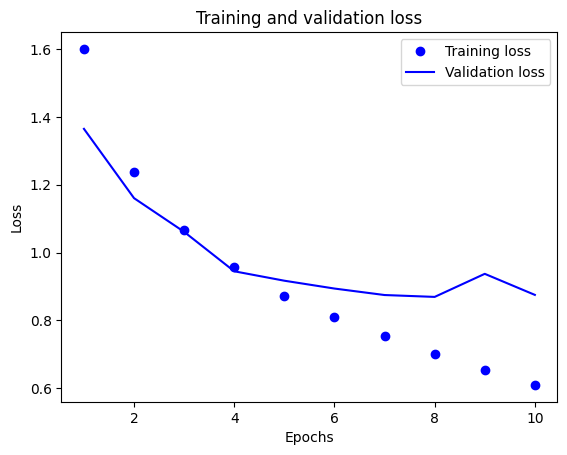

In [ ]:
# Evaluasi model pada data testing
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Visualisasi akurasi dan loss selama training
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plotting training and validation accuracy
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plotting training and validation loss
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step 


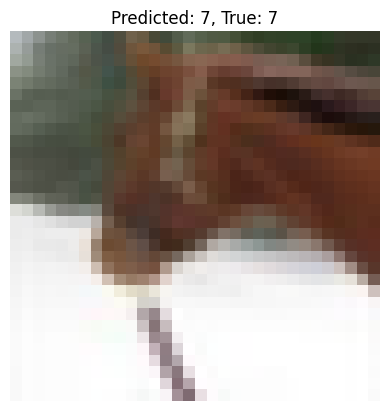

In [ ]:
# Contoh prediksi pada satu gambar dari dataset testing
for image, label in test_data.take(1):
    predictions = model.predict(image)
    pred_label = tf.argmax(predictions[0]).numpy()
    true_label = label[0].numpy()

    # Menampilkan gambar dan hasil prediksi
    plt.imshow(image[0])
    plt.title(f"Predicted: {pred_label}, True: {true_label}")
    plt.axis('off')
    plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step


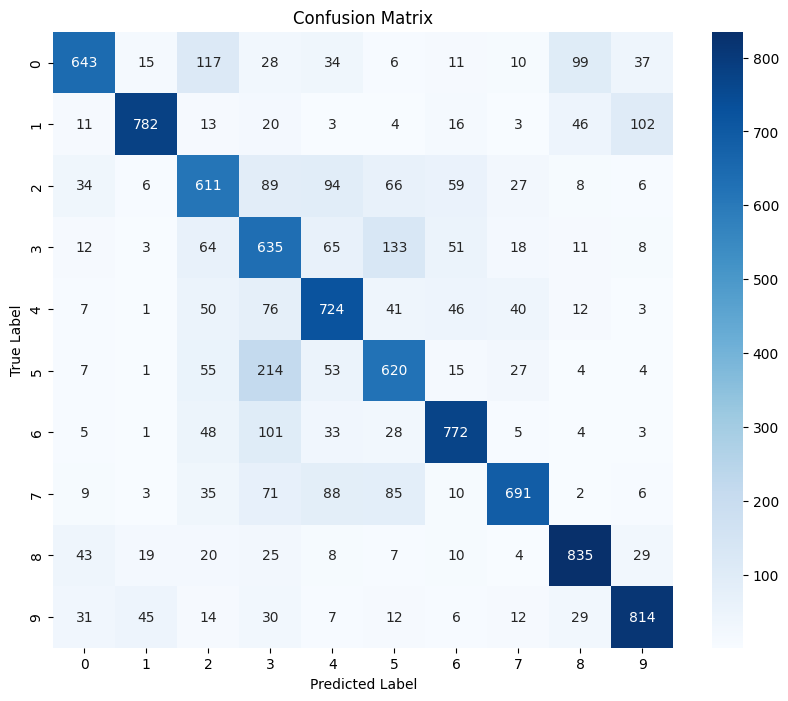

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Membuat prediksi pada seluruh dataset testing
y_pred_prob = model.predict(test_data)
y_pred = np.argmax(y_pred_prob, axis=1)

# Mendapatkan label asli dari dataset testing
y_true = []
for _, label in test_data:
  y_true.extend(label.numpy())

# Menghitung confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Menampilkan confusion matrix dengan seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# NLP with Tensorflow

In [21]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [22]:
# Memuat dataset IMDB dari tensorflow_datasets
dataset, info = tfds.load('imdb_reviews', with_info=True, as_supervised=True)

# Membagi dataset menjadi data training dan data testing
train_data, test_data = dataset['train'], dataset['test']

In [23]:
info

tfds.core.DatasetInfo(
    name='imdb_reviews',
    full_name='imdb_reviews/plain_text/1.0.0',
    description="""
    Large Movie Review Dataset. This is a dataset for binary sentiment
    classification containing substantially more data than previous benchmark
    datasets. We provide a set of 25,000 highly polar movie reviews for training,
    and 25,000 for testing. There is additional unlabeled data for use as well.
    """,
    config_description="""
    Plain text
    """,
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    data_dir='/root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0',
    file_format=tfrecord,
    download_size=80.23 MiB,
    dataset_size=129.83 MiB,
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
        'text': Text(shape=(), dtype=string),
    }),
    supervised_keys=('text', 'label'),
    disable_shuffling=False,
    splits={
        'test': <SplitInfo num_examples=25000, num_shards=1>,
    

In [24]:
# Mengatur batch size
BUFFER_SIZE = 10000
BATCH_SIZE = 64

# Fungsi untuk membuat tokenizer (tokenization) dan padding pada data teks
tokenizer = tf.keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=120)

# Melatih tokenizer menggunakan data training
train_text = train_data.map(lambda text, label: text)
tokenizer.adapt(train_text)

# Fungsi untuk memproses dataset (tokenization + padding)
def prepare_data(text, label):
    text = tokenizer(text)  # Mengubah teks menjadi token
    return text, label

# Menerapkan fungsi prepare_data pada dataset
train_data = train_data.map(prepare_data).shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_data = test_data.map(prepare_data).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [25]:
# Membangun model untuk sentiment analysis
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=10000, output_dim=16, input_length=120),  # Embedding layer
    tf.keras.layers.GlobalAveragePooling1D(),  # Pooling untuk meratakan hasil embedding
    tf.keras.layers.Dense(16, activation='relu'),  # Hidden layer
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer dengan sigmoid untuk klasifikasi biner
])

# Compile model dengan optimizer Adam dan fungsi loss Binary Crossentropy
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [26]:
# Melatih model dengan early stopping
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.6024 - loss: 0.6669 - val_accuracy: 0.7956 - val_loss: 0.4772
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.8266 - loss: 0.4140 - val_accuracy: 0.8175 - val_loss: 0.3994
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.8663 - loss: 0.3194 - val_accuracy: 0.8326 - val_loss: 0.3713
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.8914 - loss: 0.2702 - val_accuracy: 0.8318 - val_loss: 0.3803
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.9015 - loss: 0.2418 - val_accuracy: 0.8284 - val_loss: 0.3974
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9170 - loss: 0.2175 - val_accuracy: 0.8315 - val_loss: 0.3989
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.9292 - loss: 0.1921 - val_accuracy: 0.8275 - val_loss: 0.4183
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9350 - loss: 0.1810 - 

391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8181 - loss: 0.4978
Test Accuracy: 0.8153


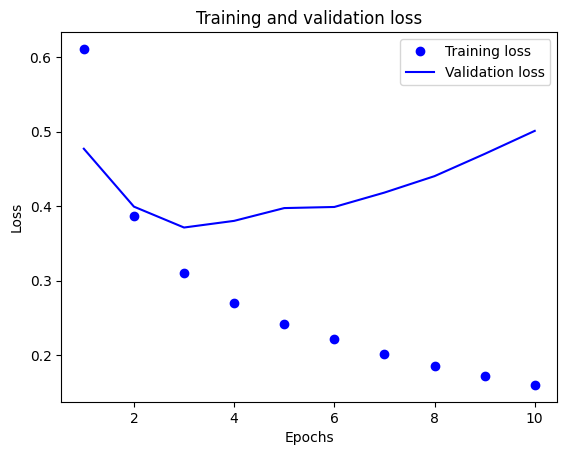

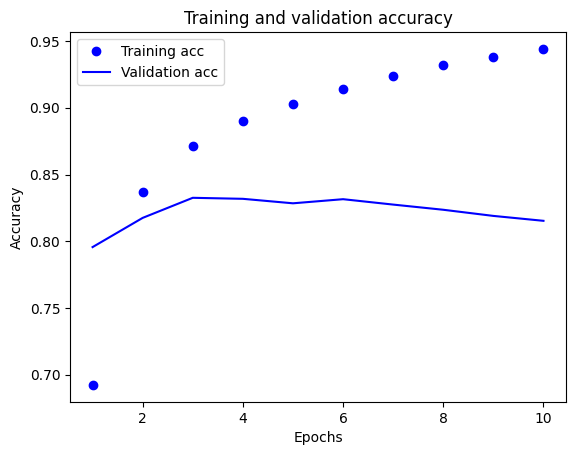

In [27]:
# Evaluasi model pada data testing
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Visualisasi akurasi dan loss selama training
history_dict = history.history
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

# Plotting training and validation loss
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plotting training and validation accuracy
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [28]:
# Contoh ulasan film baru
new_review = ["The movie was fantastic! I really enjoyed it."]
new_review_tokenized = tokenizer(new_review)

# Melakukan prediksi
prediction = model.predict(new_review_tokenized)
sentiment = "positive" if prediction >= 0.5 else "negative"
print(f"Predicted sentiment: {sentiment}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted sentiment: positive
